In [2]:
import sys
import os
project_root = os.path.dirname(os.path.dirname(os.path.abspath(os.getcwd())))
sys.path.append(str(project_root))

In [3]:
import os
import plotly.express as px
import matplotlib.pyplot as plt
import pandas as pd
from datasets import Dataset as HFDataset
from flwr_datasets.partitioner import DirichletPartitioner
from flwr_datasets.visualization import plot_label_distributions
import seaborn as sns
from configs.config_loader import load_datasets_config, load_federated_config

/Users/mustafaaktas/anaconda3/envs/Federated-Learning-Comparative-Study/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [11]:
DATASET = "hmeq"

dataset_config = load_datasets_config()[DATASET]
federated_config = load_federated_config()["ml_pipeline_experiments"]

label_name = dataset_config["target"]

CURRENT_FILE_DIR = os.path.dirname(os.path.dirname(os.path.abspath(os.getcwd())))

data_path = str(os.path.join(CURRENT_FILE_DIR, dataset_config["path"]))
df = pd.read_csv("/Users/mustafaaktas/Downloads/hmeq.csv")

In [12]:
df.head()

,BAD,LOAN,MORTDUE,VALUE,REASON,JOB,YOJ,DEROG,DELINQ,CLAGE,NINQ,CLNO,DEBTINC
0,1,1100,25860.0,39025.0,HomeImp,Other,10.5,0.0,0.0,94.366667,1.0,9.0,NaN
1,1,1300,70053.0,68400.0,HomeImp,Other,7.0,0.0,2.0,121.833333,0.0,14.0,NaN
2,1,1500,13500.0,16700.0,HomeImp,Other,4.0,0.0,0.0,149.466667,1.0,10.0,NaN
3,1,1500,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,0,1700,97800.0,112000.0,HomeImp,Office,3.0,0.0,0.0,93.333333,0.0,14.0,NaN


In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5960 entries, 0 to 5959
Data columns (total 13 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   BAD      5960 non-null   int64  
 1   LOAN     5960 non-null   int64  
 2   MORTDUE  5442 non-null   float64
 3   VALUE    5848 non-null   float64
 4   REASON   5708 non-null   object 
 5   JOB      5681 non-null   object 
 6   YOJ      5445 non-null   float64
 7   DEROG    5252 non-null   float64
 8   DELINQ   5380 non-null   float64
 9   CLAGE    5652 non-null   float64
 10  NINQ     5450 non-null   float64
 11  CLNO     5738 non-null   float64
 12  DEBTINC  4693 non-null   float64
dtypes: float64(9), int64(2), object(2)
memory usage: 605.4+ KB


In [14]:
df.describe()

,BAD,LOAN,MORTDUE,VALUE,YOJ,DEROG,DELINQ,CLAGE,NINQ,CLNO,DEBTINC
count,5960.000000,5960.000000,5442.000000,5848.000000,5445.000000,5252.000000,5380.000000,5652.000000,5450.000000,5738.000000,4693.000000
mean,0.199497,18607.969799,73760.817200,101776.048741,8.922268,0.254570,0.449442,179.766275,1.186055,21.296096,33.779915
std,0.399656,11207.480417,44457.609458,57385.775334,7.573982,0.846047,1.127266,85.810092,1.728675,10.138933,8.601746
min,0.000000,1100.000000,2063.000000,8000.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.524499
25%,0.000000,11100.000000,46276.000000,66075.500000,3.000000,0.000000,0.000000,115.116702,0.000000,15.000000,29.140031
50%,0.000000,16300.000000,65019.000000,89235.500000,7.000000,0.000000,0.000000,173.466667,1.000000,20.000000,34.818262
75%,0.000000,23300.000000,91488.000000,119824.250000,13.000000,0.000000,0.000000,231.562278,2.000000,26.000000,39.003141
max,1.000000,89900.000000,399550.000000,855909.000000,41.000000,10.000000,15.000000,1168.233561,17.000000,71.000000,203.312149


In [15]:
missing = df.isnull().sum()
missing_percent = 100 * missing / len(df)
missing_df = pd.DataFrame({
    'Number of Nulls': missing,
    'Percentage (%)': missing_percent
}).sort_values(by='Number of Nulls', ascending=False)

missing_df[missing_df["Number of Nulls"] > 0]

,Number of Nulls,Percentage (%)
DEBTINC,1267,21.258389
DEROG,708,11.879195
DELINQ,580,9.731544
MORTDUE,518,8.691275
YOJ,515,8.640940
NINQ,510,8.557047
CLAGE,308,5.167785
JOB,279,4.681208
REASON,252,4.228188
CLNO,222,3.724832


/var/folders/w2/h_x3xv0d2616hcyyqp9k7yjh0000gn/T/ipykernel_7639/1294538468.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


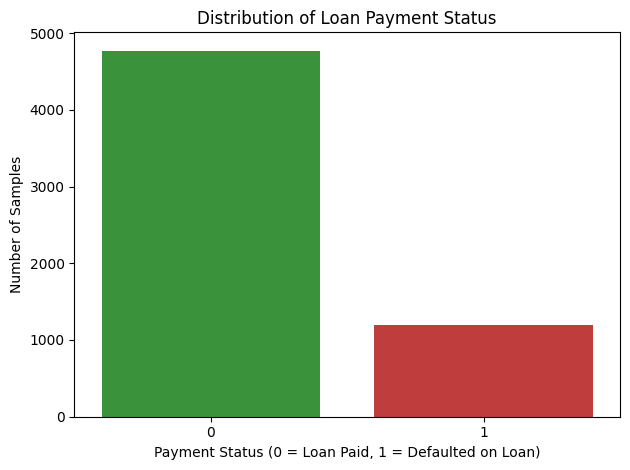

In [16]:
target_col = 'BAD'
counts = df[target_col].value_counts().reset_index()
counts.columns = [target_col, 'count']

# Plot
sns.barplot(
    data=counts,
    x=target_col,
    y='count',
    palette=['#2ca02c', '#d62728']  # green for 0, red for 1
)
plt.xlabel('Payment Status (0 = Loan Paid, 1 = Defaulted on Loan)')
plt.ylabel('Number of Samples')
plt.title('Distribution of Loan Payment Status')
plt.xticks([0, 1])
plt.tight_layout()

plt.savefig("default_graph_hmeq.png")

plt.show()

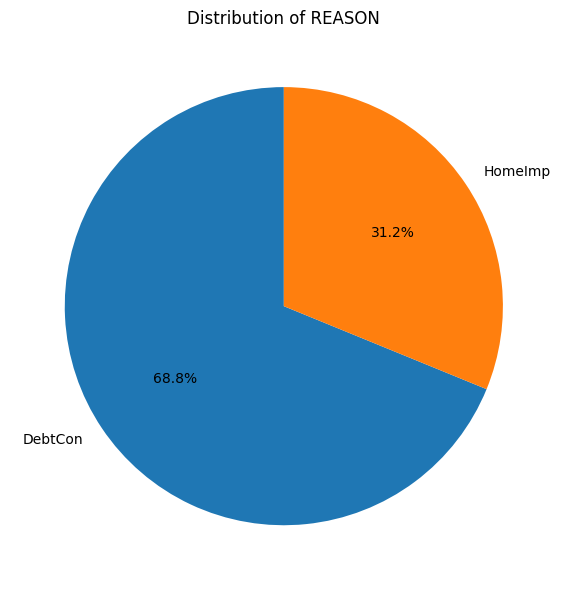

<Figure size 600x600 with 0 Axes>

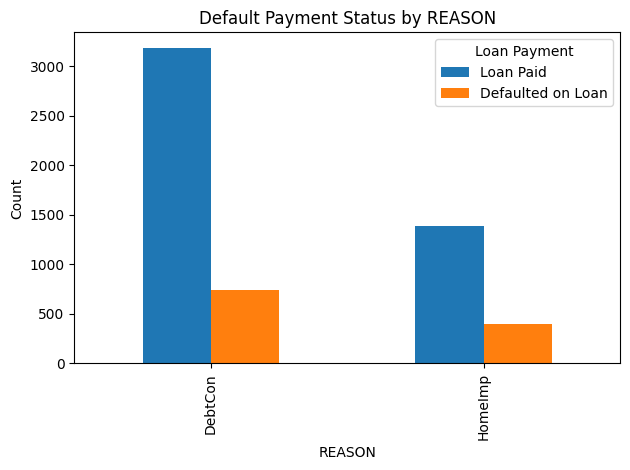

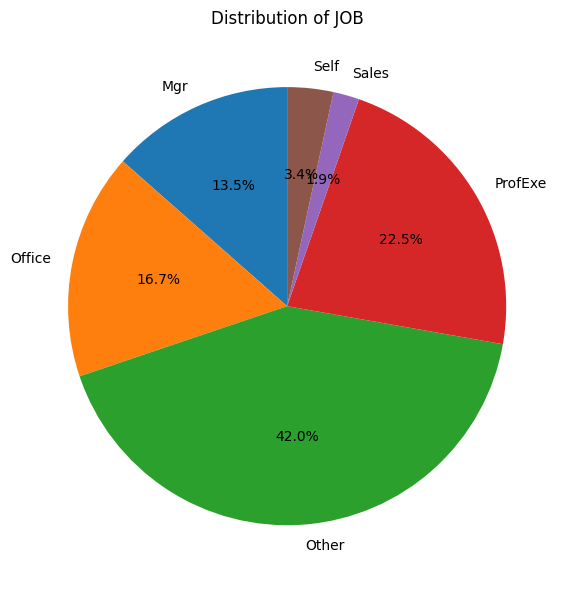

<Figure size 600x600 with 0 Axes>

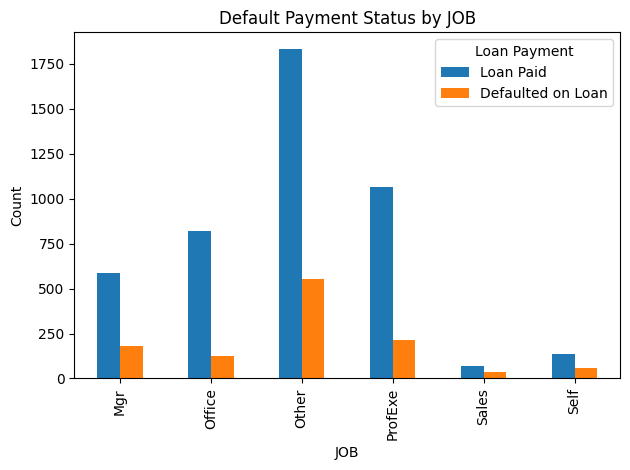

In [18]:
cols = ['REASON','JOB']

for col in cols:
    # Pie chart for distribution
    counts = df[col].value_counts().sort_index()
    plt.figure(figsize=(6, 6))
    counts.plot.pie(autopct='%1.1f%%', labels=counts.index, startangle=90)
    plt.title(f'Distribution of {col}')
    plt.ylabel('')
    plt.tight_layout()
    plt.savefig(f"{col}_pie_hmeq.png")
    plt.show()
    
    # Bar chart for default status by category
    plt.figure(figsize=(6, 6))
    default_counts = df.groupby(col)['BAD'] \
                       .value_counts().unstack(fill_value=0)
    default_counts.plot(kind='bar')
    plt.xlabel(col)
    plt.ylabel('Count')
    plt.title(f'Default Payment Status by {col}')
    plt.legend(['Loan Paid', 'Defaulted on Loan'], title='Loan Payment')
    plt.tight_layout()
    plt.savefig(f"{col}_bar_hmeq.png")
    plt.show()

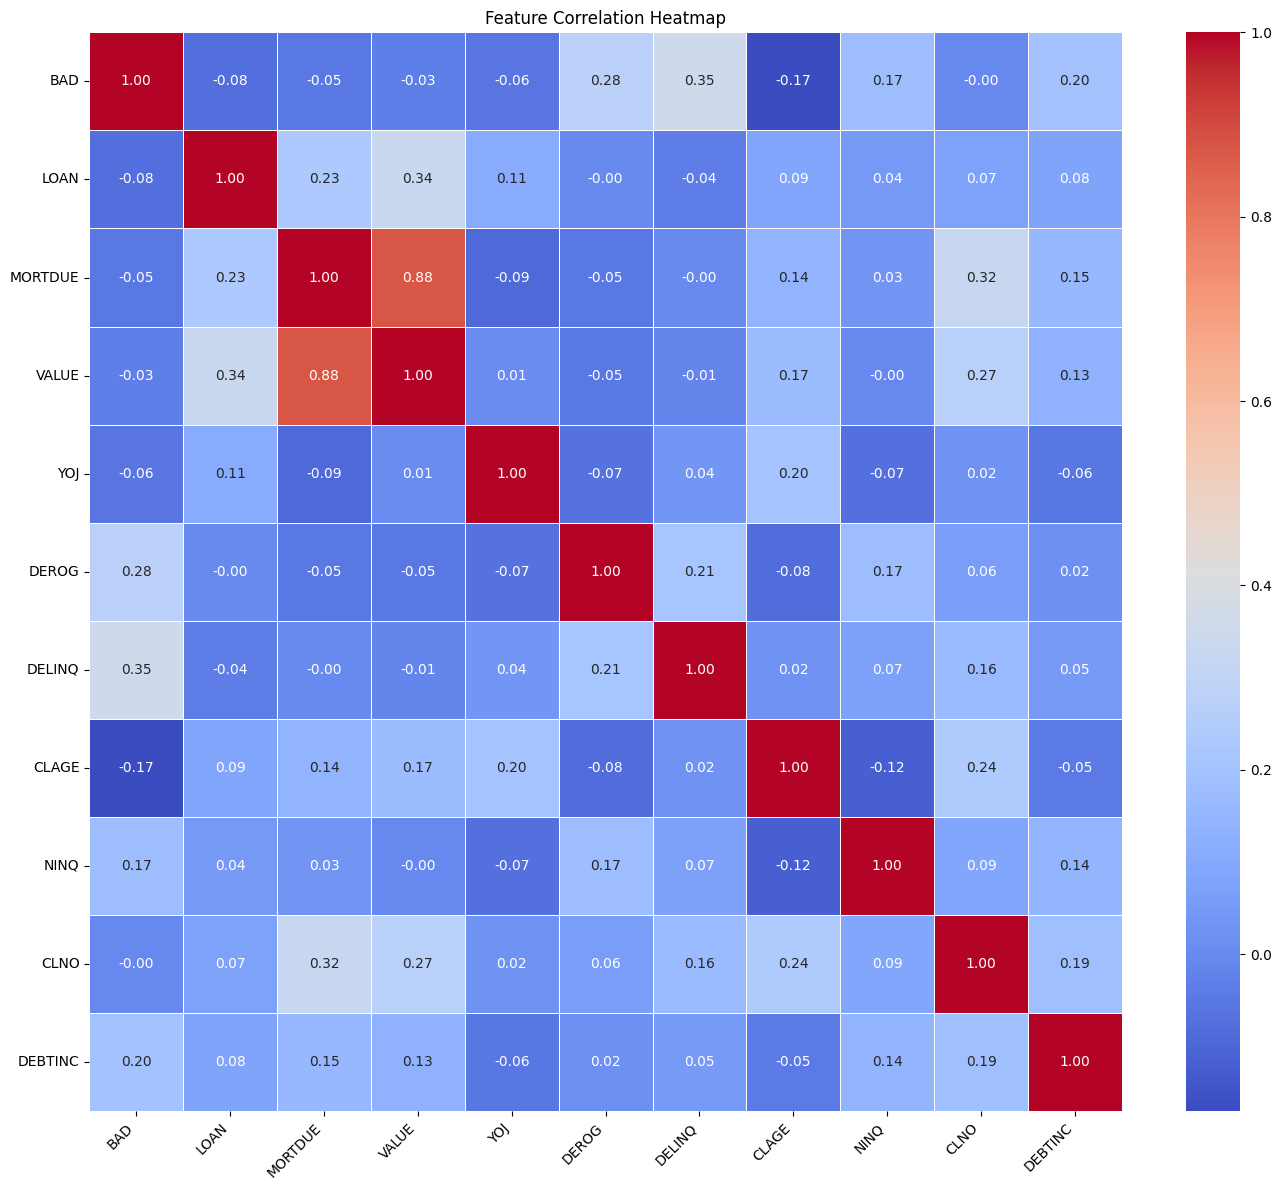

In [19]:
numeric_df = df.select_dtypes(include=['int64', 'float64'])

# Compute correlation matrix on numeric data only
corr = numeric_df.corr()

# Plot heatmap
plt.figure(figsize=(14, 12))
sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    cbar=True,
    linewidths=0.5
)
plt.title("Feature Correlation Heatmap")
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig(f"heatmap_hmeq.png")
plt.show()